# 04 — Select Top-5 Designs (extremos + compromiso + diversidad)




In [33]:
import os
import json
import itertools
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

RANDOM_SEED = 42
rng = np.random.default_rng(RANDOM_SEED)

# =========================================================
# RUTA BASE DEL PROYECTO
# =========================================================

# raíz del proyecto
DIR_PROYECTO = "."

# carpeta Transformados
DIR_DATOS_TRANSF = os.path.join(
    DIR_PROYECTO,
    "Datos",
    "Transformados",
    "Optimizacion"
)

# salida del MOEA (Notebook 03)
DIR_MOEA = os.path.join(
    DIR_DATOS_TRANSF,
    "outputs",
    "moea"
)

# salida del Notebook 04
OUT_DIR = os.path.join(
    DIR_DATOS_TRANSF,
    "outputs",
    "top5"
)

FIG_DIR = os.path.join(
    OUT_DIR,
    "figures"
)

os.makedirs(OUT_DIR, exist_ok=True)
os.makedirs(FIG_DIR, exist_ok=True)

pd.set_option("display.max_columns", 200)

print("DIR_DATOS_TRANSF:", DIR_DATOS_TRANSF)
print("DIR_MOEA:", DIR_MOEA)
print("OUT_DIR :", OUT_DIR)
print("FIG_DIR :", FIG_DIR)

DIR_DATOS_TRANSF: .\Datos\Transformados\Optimizacion
DIR_MOEA: .\Datos\Transformados\Optimizacion\outputs\moea
OUT_DIR : .\Datos\Transformados\Optimizacion\outputs\top5
FIG_DIR : .\Datos\Transformados\Optimizacion\outputs\top5\figures


## 1) Cargar frente final



In [34]:

# Cambia esto solo si quieres forzar un archivo concreto
ALGORITMO_FINAL = "SPEA2"

front_candidates = [
    os.path.join(DIR_MOEA, "pareto_front_mix_nsga3_spea2_top100.csv"),
    os.path.join(DIR_MOEA, f"final_front_{ALGORITMO_FINAL}.csv"),
    os.path.join(DIR_MOEA, f"final_front_{ALGORITMO_FINAL.lower()}.csv"),
    os.path.join(DIR_MOEA, f"final_front_{ALGORITMO_FINAL.upper()}.csv"),
]

RUTA_FRENTE_FINAL = None
for cand in front_candidates:
    if os.path.exists(cand):
        RUTA_FRENTE_FINAL = cand
        break

if RUTA_FRENTE_FINAL is None:
    raise FileNotFoundError(
        "No encontré el frente final. Revisé:\n" + "\n".join(front_candidates)
    )

front = pd.read_csv(RUTA_FRENTE_FINAL)

print("Frente cargado desde:", RUTA_FRENTE_FINAL)
print("Shape:", front.shape)
display(front.head())


Frente cargado desde: .\Datos\Transformados\Optimizacion\outputs\moea\pareto_front_mix_nsga3_spea2_top100.csv
Shape: (100, 14)


,algorithm,seed,hm,alpha_m,er,dsi,bst,bss,TC,TcogPP,ned,TriPP,pct_train_used,n_obs_used
0,NSGA-III,42,1.033413,0.795563,1.745611,0.848496,45.666437,5.218476,4.772104,0.017142,-0.901264,0.021820,0.6,816
1,NSGA-III,42,1.006716,0.740377,1.605082,0.845467,45.229756,4.262720,4.589282,0.015155,-0.890734,0.024423,0.6,816
2,NSGA-III,42,1.096317,0.701229,1.201047,1.000985,45.560446,4.698731,4.602548,0.008343,-0.869081,0.011418,0.6,816
3,NSGA-III,42,1.229345,0.727495,1.711954,0.926574,45.143627,4.302649,4.801830,0.009994,-0.890961,0.021618,0.6,816
4,NSGA-III,42,1.070649,0.700232,1.791302,0.940682,45.191498,4.996809,4.562009,0.005034,-0.870108,0.019894,0.6,816


In [35]:

# =========================================
# Inferir columnas reales
# =========================================
X_cols = [c for c in ["hm", "alpha_m", "er", "dsi", "bst", "bss"] if c in front.columns]
Y_cols = [c for c in ["TC", "TcogPP", "ned", "TriPP"] if c in front.columns]

assert len(X_cols) == 6, f"No detecté las 6 variables de diseño. Detecté: {X_cols}"
assert len(Y_cols) == 4, f"No detecté los 4 objetivos. Detecté: {Y_cols}"

print("X_cols:", X_cols)
print("Y_cols:", Y_cols)


X_cols: ['hm', 'alpha_m', 'er', 'dsi', 'bst', 'bss']
Y_cols: ['TC', 'TcogPP', 'ned', 'TriPP']


## 2) Normalización de objetivos



In [36]:

F = front[Y_cols].values.astype(float)

F_min = F.min(axis=0)
F_max = F.max(axis=0)
den = np.where((F_max - F_min) < 1e-12, 1.0, (F_max - F_min))

Fn = (F - F_min) / den
Fn = np.clip(Fn, 0.0, 1.0)

ideal = np.zeros(Fn.shape[1])
dist_to_ideal = np.linalg.norm(Fn - ideal[None, :], axis=1)

front_scored = front.copy()
front_scored["dist_to_ideal"] = dist_to_ideal

for j, obj in enumerate(Y_cols):
    front_scored[f"{obj}_norm"] = Fn[:, j]

norm_cols = [f"{obj}_norm" for obj in Y_cols]

print("Rangos por objetivo:")
for i, obj in enumerate(Y_cols):
    print(f"  {obj}: min={F_min[i]:.6f} max={F_max[i]:.6f}")

display(front_scored.head())


Rangos por objetivo:
  TC: min=4.372008 max=8.239549
  TcogPP: min=0.000427 max=0.215184
  ned: min=-0.921662 max=-0.708305
  TriPP: min=0.001917 max=0.231837


,algorithm,seed,hm,alpha_m,er,dsi,bst,bss,TC,TcogPP,ned,TriPP,pct_train_used,n_obs_used,dist_to_ideal,TC_norm,TcogPP_norm,ned_norm,TriPP_norm
0,NSGA-III,42,1.033413,0.795563,1.745611,0.848496,45.666437,5.218476,4.772104,0.017142,-0.901264,0.021820,0.6,816,0.182738,0.103450,0.077833,0.095603,0.086563
1,NSGA-III,42,1.006716,0.740377,1.605082,0.845467,45.229756,4.262720,4.589282,0.015155,-0.890734,0.024423,0.6,816,0.196095,0.056179,0.068582,0.144956,0.097885
2,NSGA-III,42,1.096317,0.701229,1.201047,1.000985,45.560446,4.698731,4.602548,0.008343,-0.869081,0.011418,0.6,816,0.259529,0.059609,0.036859,0.246447,0.041322
3,NSGA-III,42,1.229345,0.727495,1.711954,0.926574,45.143627,4.302649,4.801830,0.009994,-0.890961,0.021618,0.6,816,0.205873,0.111136,0.044550,0.143895,0.085685
4,NSGA-III,42,1.070649,0.700232,1.791302,0.940682,45.191498,4.996809,4.562009,0.005034,-0.870108,0.019894,0.6,816,0.259565,0.049127,0.021453,0.241634,0.078189


## 3) Selección Top-5

Estrategia:
1. seleccionar soluciones **extremas** (una por objetivo),
2. añadir la mejor solución de **compromiso global** (mínima distancia al ideal),
3. si aún no hay 5 diseños distintos, completar maximizando **diversidad**.


In [37]:

def pairwise_dist(A, B):
    return np.sqrt(((A[:, None, :] - B[None, :, :]) ** 2).sum(axis=2))

selected_indices = []
selection_reason = {}

# 1) Extremos por objetivo (mínimos)
for obj in Y_cols:
    idx = int(front_scored[obj].idxmin())
    if idx not in selected_indices:
        selected_indices.append(idx)
        selection_reason[idx] = f"extreme_{obj}"

# 2) Compromiso global (knee / punto más cercano al ideal)
knee_idx = int(front_scored["dist_to_ideal"].idxmin())
if knee_idx not in selected_indices:
    selected_indices.append(knee_idx)
    selection_reason[knee_idx] = "knee_global"
else:
    # si el knee coincide con un extremo, deja trazabilidad
    selection_reason[knee_idx] = selection_reason.get(knee_idx, "") + "|knee_global"

# 3) Completar hasta 5 maximizando diversidad
D = pairwise_dist(Fn, Fn)

while len(selected_indices) < 5:
    remaining = [i for i in range(Fn.shape[0]) if i not in selected_indices]
    min_dist = D[remaining][:, selected_indices].min(axis=1)

    # Entre los más diversos, priorizar también buen compromiso
    tmp = pd.DataFrame({
        "front_index": remaining,
        "min_dist": min_dist,
        "dist_to_ideal": front_scored.loc[remaining, "dist_to_ideal"].values
    })

    # normalización local
    tmp["min_dist_n"] = tmp["min_dist"] / (tmp["min_dist"].max() + 1e-12)
    dmin, dmax = tmp["dist_to_ideal"].min(), tmp["dist_to_ideal"].max()
    tmp["ideal_n"] = (tmp["dist_to_ideal"] - dmin) / (dmax - dmin + 1e-12)

    # score mixto: 60% diversidad, 40% compromiso
    tmp["combo"] = 0.6 * tmp["min_dist_n"] + 0.4 * (1 - tmp["ideal_n"])

    chosen = int(tmp.sort_values("combo", ascending=False).iloc[0]["front_index"])
    selected_indices.append(chosen)
    selection_reason[chosen] = "diversity_fill"

top5 = front_scored.loc[selected_indices].copy().reset_index(drop=False).rename(columns={"index": "front_index"})
top5["design_id"] = [f"D{i+1}" for i in range(len(top5))]
top5["selection_reason"] = top5["front_index"].map(selection_reason)

display(top5[["design_id", "selection_reason", *X_cols, *Y_cols, "dist_to_ideal"]])


,design_id,selection_reason,hm,alpha_m,er,dsi,bst,bss,TC,TcogPP,ned,TriPP,dist_to_ideal
0,D1,extreme_TC,1.029170,0.704968,1.876556,2.419756,45.013288,4.271792,4.372008,0.012100,-0.750121,0.028520,0.814108
1,D2,extreme_TcogPP,3.245744,0.998233,1.904750,2.351708,45.049266,5.021003,7.287545,0.000427,-0.802578,0.001917,0.937983
2,D3,extreme_ned,2.455633,0.899500,1.654304,0.082119,45.059758,5.111363,6.681814,0.064879,-0.921662,0.104511,0.803657
3,D4,knee_global,1.033413,0.795563,1.745611,0.848496,45.666437,5.218476,4.772104,0.017142,-0.901264,0.021820,0.182738
4,D5,diversity_fill,1.008749,0.921655,0.978896,0.030524,45.052025,4.815416,5.000045,0.215184,-0.916638,0.231837,1.423701


## 4) Sanity checks

In [38]:

def dominates(a, b):
    return np.all(a <= b) and np.any(a < b)

F5 = top5[Y_cols].values.astype(float)

violations = []
for i in range(F5.shape[0]):
    for j in range(F5.shape[0]):
        if i == j:
            continue
        if dominates(F5[i], F5[j]):
            violations.append((i, j))

if violations:
    print("Hay relaciones de dominancia dentro del Top-5:")
    for i, j in violations:
        print(f"  {top5.loc[i, 'design_id']} domina a {top5.loc[j, 'design_id']}")
else:
    print("No hay dominancia entre las Top-5 seleccionadas.")


No hay dominancia entre las Top-5 seleccionadas.


In [39]:

print("Resumen Top-5:")
display(top5[["design_id", "selection_reason", *Y_cols, "dist_to_ideal"]])

print("\nDescriptivos del frente completo:")
display(front[Y_cols].describe().T)

print("\nDescriptivos del Top-5:")
display(top5[Y_cols].describe().T)


Resumen Top-5:


,design_id,selection_reason,TC,TcogPP,ned,TriPP,dist_to_ideal
0,D1,extreme_TC,4.372008,0.012100,-0.750121,0.028520,0.814108
1,D2,extreme_TcogPP,7.287545,0.000427,-0.802578,0.001917,0.937983
2,D3,extreme_ned,6.681814,0.064879,-0.921662,0.104511,0.803657
3,D4,knee_global,4.772104,0.017142,-0.901264,0.021820,0.182738
4,D5,diversity_fill,5.000045,0.215184,-0.916638,0.231837,1.423701



Descriptivos del frente completo:


,count,mean,std,min,25%,50%,75%,max
TC,100.0,5.670438,1.037008,4.372008,4.817140,5.295343,6.337285,8.239549
TcogPP,100.0,0.044390,0.048885,0.000427,0.008147,0.028769,0.057929,0.215184
ned,100.0,-0.882509,0.051630,-0.921662,-0.916615,-0.904382,-0.872098,-0.708305
TriPP,100.0,0.058494,0.055697,0.001917,0.019167,0.039562,0.074006,0.231837



Descriptivos del Top-5:


,count,mean,std,min,25%,50%,75%,max
TC,5.0,5.622703,1.281491,4.372008,4.772104,5.000045,6.681814,7.287545
TcogPP,5.0,0.061946,0.089117,0.000427,0.012100,0.017142,0.064879,0.215184
ned,5.0,-0.858453,0.077575,-0.921662,-0.916638,-0.901264,-0.802578,-0.750121
TriPP,5.0,0.077721,0.094553,0.001917,0.021820,0.028520,0.104511,0.231837


## 5) Gráficos


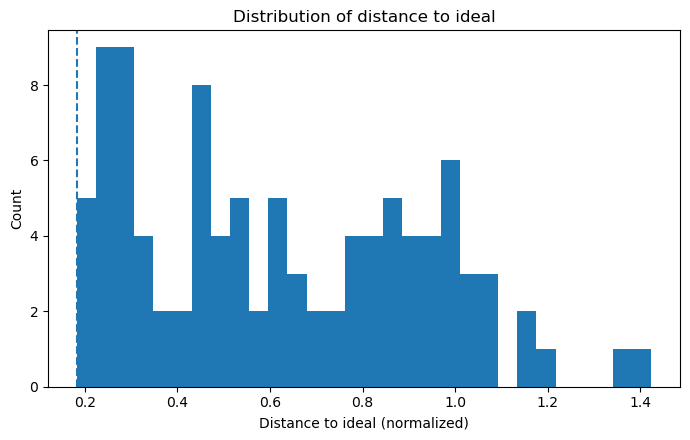

Saved: .\Datos\Transformados\Optimizacion\outputs\top5\figures\dist_to_ideal_hist.png


In [40]:

# Histograma de distancia al ideal
plt.figure(figsize=(7, 4.5))
plt.hist(front_scored["dist_to_ideal"], bins=30)
plt.axvline(front_scored.loc[knee_idx, "dist_to_ideal"], linestyle="--")
plt.xlabel("Distance to ideal (normalized)")
plt.ylabel("Count")
plt.title("Distribution of distance to ideal")
plt.tight_layout()

hist_path = os.path.join(FIG_DIR, "dist_to_ideal_hist.png")
plt.savefig(hist_path, dpi=200, bbox_inches="tight")
plt.show()

print("Saved:", hist_path)


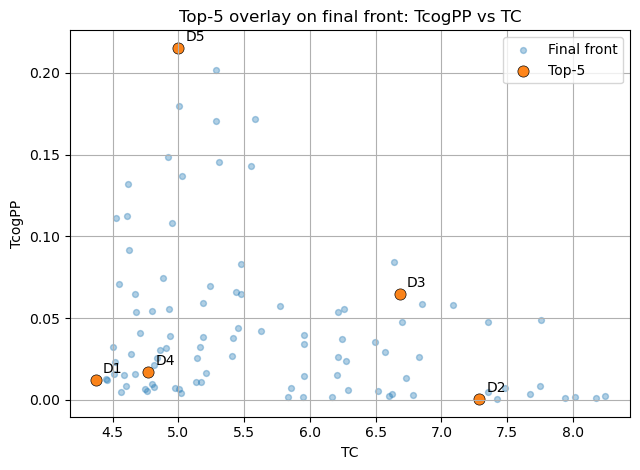

Saved: .\Datos\Transformados\Optimizacion\outputs\top5\figures\overlay_TcogPP_vs_TC.png


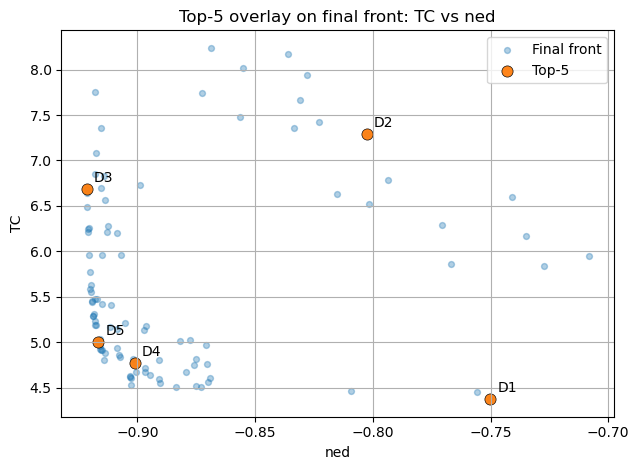

Saved: .\Datos\Transformados\Optimizacion\outputs\top5\figures\overlay_TC_vs_ned.png


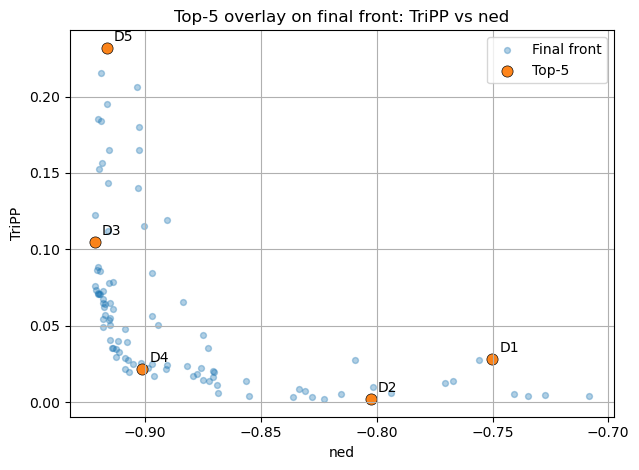

Saved: .\Datos\Transformados\Optimizacion\outputs\top5\figures\overlay_TriPP_vs_ned.png


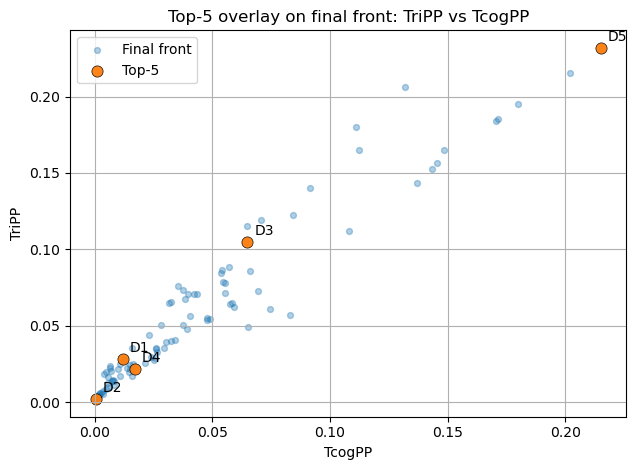

Saved: .\Datos\Transformados\Optimizacion\outputs\top5\figures\overlay_TriPP_vs_TcogPP.png


In [41]:

def plot_top5_overlay(front_df, top5_df, x, y, path=None, title=None):
    plt.figure(figsize=(6.5, 4.8))

    plt.scatter(
        front_df[x], front_df[y],
        s=18, alpha=0.35,
        label="Final front"
    )

    plt.scatter(
        top5_df[x], top5_df[y],
        s=65, alpha=0.95,
        edgecolors="k", linewidths=0.5,
        label="Top-5"
    )

    for _, row in top5_df.iterrows():
        plt.annotate(
            row["design_id"],
            (row[x], row[y]),
            textcoords="offset points",
            xytext=(5, 5)
        )

    plt.xlabel(x)
    plt.ylabel(y)
    plt.title(title or f"Top-5 overlay on final front: {y} vs {x}")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()

    if path is not None:
        plt.savefig(path, dpi=220, bbox_inches="tight")
    plt.show()

# Dos overlays clave
overlay_pairs = [
    ("TC", "TcogPP"),
    ("ned", "TC"),
    ("ned", "TriPP"),
    ("TcogPP", "TriPP"),
]

for x, y in overlay_pairs:
    p = os.path.join(FIG_DIR, f"overlay_{y}_vs_{x}.png")
    plot_top5_overlay(front_scored, top5, x, y, path=p)
    print("Saved:", p)


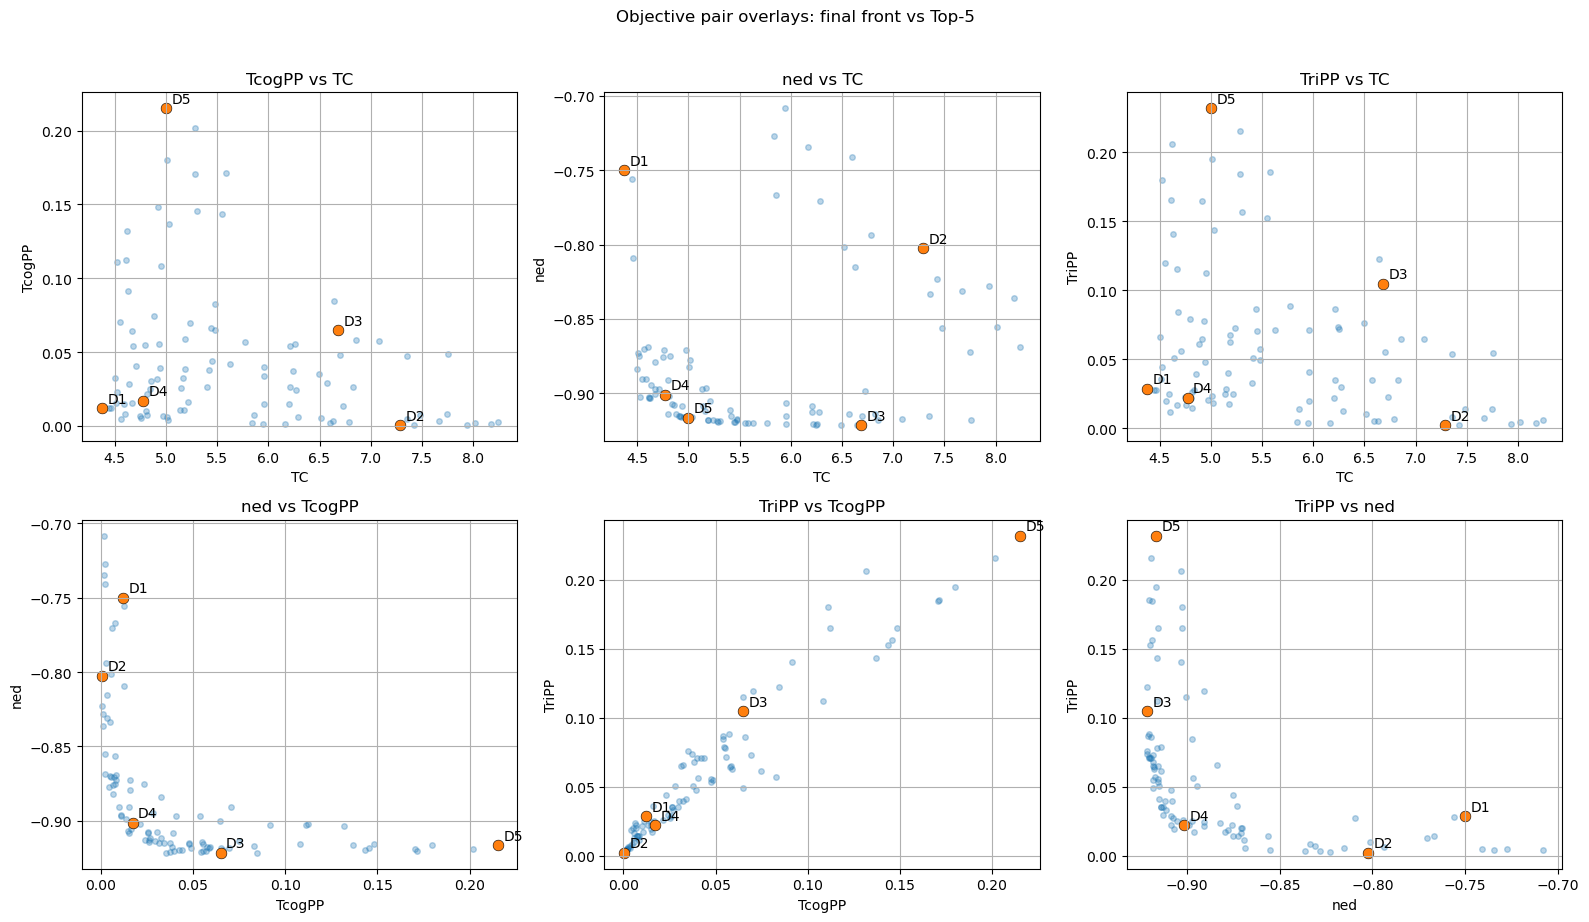

Saved: .\Datos\Transformados\Optimizacion\outputs\top5\figures\objective_pair_overlays.png


In [42]:

# Matriz de overlays de objetivos (2x3)
pairs = list(itertools.combinations(Y_cols, 2))

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.ravel()

for ax, (x, y) in zip(axes, pairs):
    ax.scatter(front_scored[x], front_scored[y], s=16, alpha=0.30)
    ax.scatter(top5[x], top5[y], s=60, edgecolors="k", linewidths=0.4)
    for _, row in top5.iterrows():
        ax.annotate(row["design_id"], (row[x], row[y]), textcoords="offset points", xytext=(4,4))
    ax.set_xlabel(x)
    ax.set_ylabel(y)
    ax.grid(True)
    ax.set_title(f"{y} vs {x}")

fig.suptitle("Objective pair overlays: final front vs Top-5", y=1.02)
fig.tight_layout()

matrix_path = os.path.join(FIG_DIR, "objective_pair_overlays.png")
plt.savefig(matrix_path, dpi=220, bbox_inches="tight")
plt.show()

print("Saved:", matrix_path)


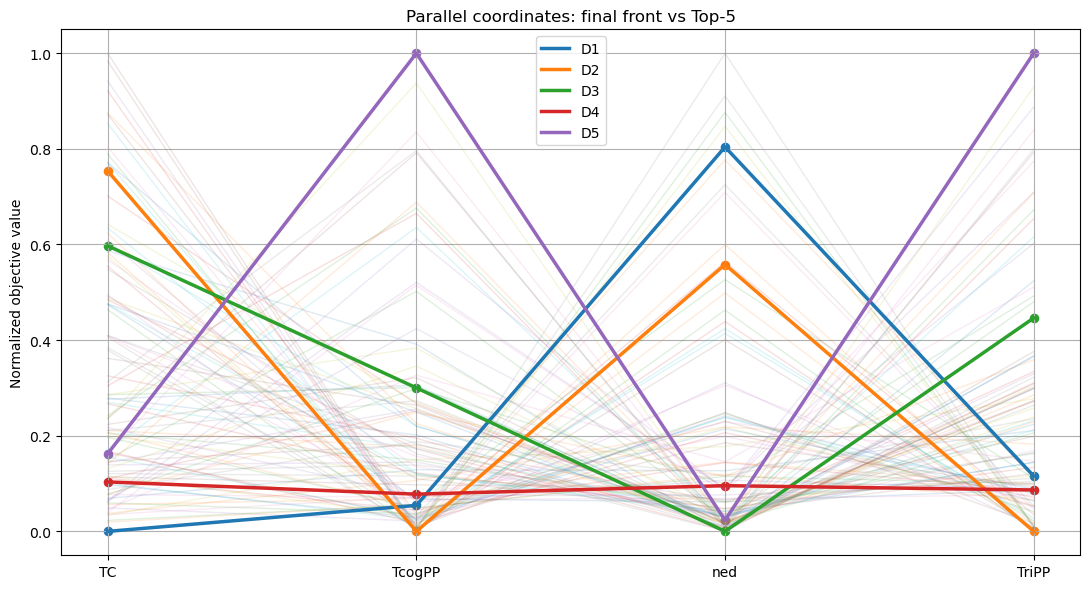

Saved: .\Datos\Transformados\Optimizacion\outputs\top5\figures\parallel_coordinates_top5.png


In [43]:

# Parallel coordinates
def plot_parallel_coordinates_top5(front_df, top5_df, y_cols, path=None):
    F_all = front_df[y_cols].values.astype(float)
    f_min = F_all.min(axis=0)
    f_max = F_all.max(axis=0)
    den = np.where((f_max - f_min) < 1e-12, 1.0, (f_max - f_min))

    F_all_n = np.clip((F_all - f_min) / den, 0.0, 1.0)
    F_top5_n = np.clip((top5_df[y_cols].values.astype(float) - f_min) / den, 0.0, 1.0)

    x = np.arange(len(y_cols))

    plt.figure(figsize=(11, 6))

    for i in range(F_all_n.shape[0]):
        plt.plot(x, F_all_n[i], alpha=0.15, linewidth=1)

    for i in range(F_top5_n.shape[0]):
        plt.plot(x, F_top5_n[i], linewidth=2.5, label=top5_df.iloc[i]["design_id"])
        plt.scatter(x, F_top5_n[i], s=35)

    plt.xticks(x, y_cols)
    plt.ylabel("Normalized objective value")
    plt.title("Parallel coordinates: final front vs Top-5")
    plt.grid(True)
    plt.legend()
    plt.tight_layout()

    if path is not None:
        plt.savefig(path, dpi=220, bbox_inches="tight")
    plt.show()

parallel_path = os.path.join(FIG_DIR, "parallel_coordinates_top5.png")
plot_parallel_coordinates_top5(front_scored, top5, Y_cols, path=parallel_path)
print("Saved:", parallel_path)


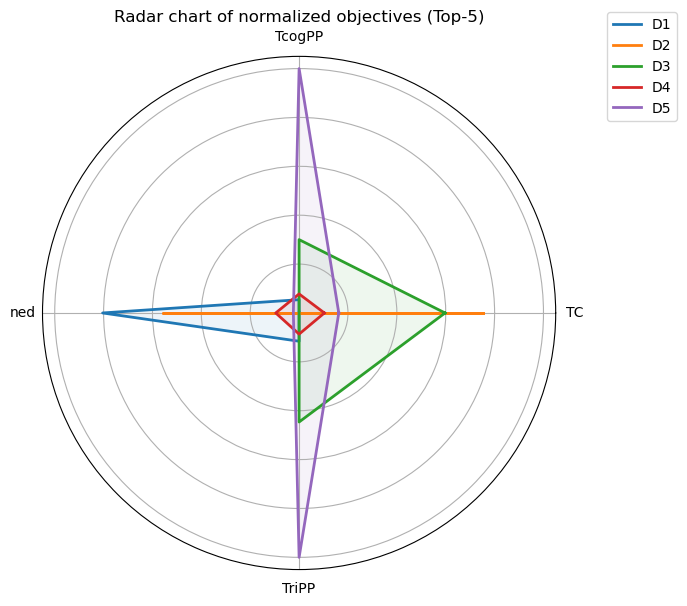

Saved: .\Datos\Transformados\Optimizacion\outputs\top5\figures\radar_top5_objectives.png


In [44]:

# Radar chart de objetivos normalizados
angles = np.linspace(0, 2 * np.pi, len(Y_cols), endpoint=False).tolist()
angles += angles[:1]

plt.figure(figsize=(7, 7))
ax = plt.subplot(111, polar=True)

for _, row in top5.iterrows():
    vals = [row[f"{obj}_norm"] for obj in Y_cols]
    vals += vals[:1]
    ax.plot(angles, vals, linewidth=2, label=row["design_id"])
    ax.fill(angles, vals, alpha=0.08)

ax.set_xticks(angles[:-1])
ax.set_xticklabels(Y_cols)
ax.set_yticklabels([])
ax.set_title("Radar chart of normalized objectives (Top-5)")
ax.legend(loc="upper right", bbox_to_anchor=(1.25, 1.1))
plt.tight_layout()

radar_path = os.path.join(FIG_DIR, "radar_top5_objectives.png")
plt.savefig(radar_path, dpi=220, bbox_inches="tight")
plt.show()

print("Saved:", radar_path)


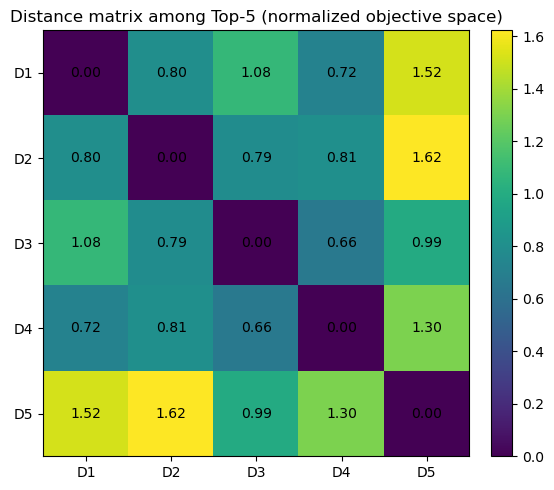

Saved: .\Datos\Transformados\Optimizacion\outputs\top5\figures\distance_matrix_top5.png


In [45]:

# Heatmap de distancias entre Top-5 en espacio objetivo normalizado
F5n = top5[[f"{obj}_norm" for obj in Y_cols]].values.astype(float)
D5 = pairwise_dist(F5n, F5n)

plt.figure(figsize=(6, 5))
im = plt.imshow(D5)
plt.colorbar(im, fraction=0.046, pad=0.04)
plt.xticks(range(len(top5)), top5["design_id"])
plt.yticks(range(len(top5)), top5["design_id"])
plt.title("Distance matrix among Top-5 (normalized objective space)")

for i in range(D5.shape[0]):
    for j in range(D5.shape[1]):
        plt.text(j, i, f"{D5[i, j]:.2f}", ha="center", va="center")

plt.tight_layout()

dist_path = os.path.join(FIG_DIR, "distance_matrix_top5.png")
plt.savefig(dist_path, dpi=220, bbox_inches="tight")
plt.show()

print("Saved:", dist_path)


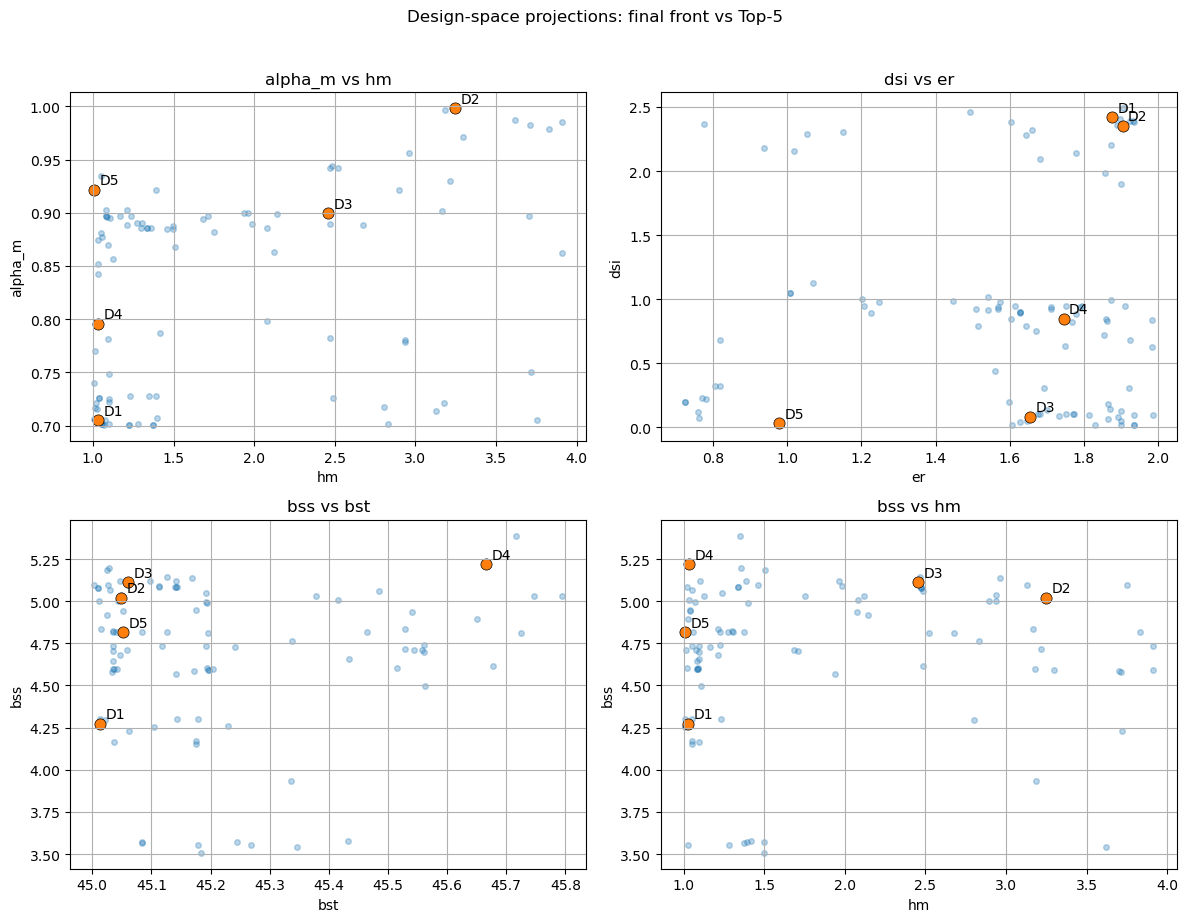

Saved: .\Datos\Transformados\Optimizacion\outputs\top5\figures\design_space_projections_top5.png


In [46]:

# Scatter matrix sencilla de variables de diseño (pares relevantes)
design_pairs = [
    ("hm", "alpha_m"),
    ("er", "dsi"),
    ("bst", "bss"),
    ("hm", "bss"),
]

fig, axes = plt.subplots(2, 2, figsize=(12, 9))
axes = axes.ravel()

for ax, (x, y) in zip(axes, design_pairs):
    ax.scatter(front_scored[x], front_scored[y], s=16, alpha=0.30)
    ax.scatter(top5[x], top5[y], s=65, edgecolors="k", linewidths=0.5)
    for _, row in top5.iterrows():
        ax.annotate(row["design_id"], (row[x], row[y]), textcoords="offset points", xytext=(4,4))
    ax.set_xlabel(x)
    ax.set_ylabel(y)
    ax.grid(True)
    ax.set_title(f"{y} vs {x}")

fig.suptitle("Design-space projections: final front vs Top-5", y=1.02)
fig.tight_layout()

design_path = os.path.join(FIG_DIR, "design_space_projections_top5.png")
plt.savefig(design_path, dpi=220, bbox_inches="tight")
plt.show()

print("Saved:", design_path)


## 6) Export final

In [47]:

top5_export = top5.copy()
top5_export = top5_export[[
    "design_id", "selection_reason", "front_index",
    *X_cols, *Y_cols,
    *norm_cols,
    "dist_to_ideal"
]]

top5_path = os.path.join(OUT_DIR, "top5_designs.csv")
top5_export.to_csv(top5_path, index=False)

summary = {
    "front_path": RUTA_FRENTE_FINAL,
    "n_front": int(len(front)),
    "selected_indices": [int(x) for x in selected_indices],
    "knee_index": int(knee_idx),
    "algorithm_hint": ALGORITMO_FINAL,
    "Y_cols": Y_cols,
    "X_cols": X_cols,
    "random_seed": int(RANDOM_SEED),
    "selection_strategy": "extremes + knee + diversity_fill",
    "figures_dir": FIG_DIR,
    "output_top5_file": top5_path
}

summary_path = os.path.join(OUT_DIR, "top5_summary.json")
with open(summary_path, "w", encoding="utf-8") as f:
    json.dump(summary, f, indent=2, ensure_ascii=False)

print("Saved:", top5_path)
print("Saved:", summary_path)
display(top5_export)


Saved: .\Datos\Transformados\Optimizacion\outputs\top5\top5_designs.csv
Saved: .\Datos\Transformados\Optimizacion\outputs\top5\top5_summary.json


,design_id,selection_reason,front_index,hm,alpha_m,er,dsi,bst,bss,TC,TcogPP,ned,TriPP,TC_norm,TcogPP_norm,ned_norm,TriPP_norm,dist_to_ideal
0,D1,extreme_TC,54,1.029170,0.704968,1.876556,2.419756,45.013288,4.271792,4.372008,0.012100,-0.750121,0.028520,0.000000,0.054356,0.804009,0.115704,0.814108
1,D2,extreme_TcogPP,78,3.245744,0.998233,1.904750,2.351708,45.049266,5.021003,7.287545,0.000427,-0.802578,0.001917,0.753848,0.000000,0.558145,0.000000,0.937983
2,D3,extreme_ned,80,2.455633,0.899500,1.654304,0.082119,45.059758,5.111363,6.681814,0.064879,-0.921662,0.104511,0.597228,0.300118,0.000000,0.446218,0.803657
3,D4,knee_global,0,1.033413,0.795563,1.745611,0.848496,45.666437,5.218476,4.772104,0.017142,-0.901264,0.021820,0.103450,0.077833,0.095603,0.086563,0.182738
4,D5,diversity_fill,99,1.008749,0.921655,0.978896,0.030524,45.052025,4.815416,5.000045,0.215184,-0.916638,0.231837,0.162387,1.000000,0.023546,1.000000,1.423701
